In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('final preprocessed and cleaned data.csv')

In [3]:
df.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking,obesity_level
0,-0.458052,-0.787962,0.387607,-0.014691,-1.201111,0.517125,-0.652922,0,1,0,...,0,0,0,0,1,0,0,1,0,1
1,-0.458052,1.062931,0.387607,1.636239,2.324961,-1.127965,-0.671104,0,1,0,...,1,1,0,1,0,0,0,1,0,1
2,-0.008186,-0.787962,0.387607,-0.014691,1.149604,0.517125,-0.729071,1,1,0,...,0,0,1,0,0,0,0,1,0,1
3,0.788805,1.062931,0.387607,-0.014691,1.149604,-1.127965,-0.350662,1,0,0,...,0,0,1,0,0,0,0,0,1,5
4,-0.228227,-0.787962,-2.230910,-0.014691,-1.201111,-1.127965,-0.167916,1,0,0,...,0,0,0,1,0,0,0,1,0,6


In [4]:
x = df.drop(columns='obesity_level')
y = df['obesity_level']

In [5]:
x.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,food_bw_meals_no,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking
0,-0.458052,-0.787962,0.387607,-0.014691,-1.201111,0.517125,-0.652922,0,1,0,...,0,0,0,0,0,1,0,0,1,0
1,-0.458052,1.062931,0.387607,1.636239,2.324961,-1.127965,-0.671104,0,1,0,...,0,1,1,0,1,0,0,0,1,0
2,-0.008186,-0.787962,0.387607,-0.014691,1.149604,0.517125,-0.729071,1,1,0,...,0,0,0,1,0,0,0,0,1,0
3,0.788805,1.062931,0.387607,-0.014691,1.149604,-1.127965,-0.350662,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,-0.228227,-0.787962,-2.230910,-0.014691,-1.201111,-1.127965,-0.167916,1,0,0,...,0,0,0,0,1,0,0,0,1,0


In [6]:
y.head()

0    1
1    1
2    1
3    5
4    6
Name: obesity_level, dtype: int64

In [7]:
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [8]:
x_train.head()

,Age,use_vegetables,num_meals_daily,CH2O,physical_activity,use_technological_devices,BMI,Gender_Male,family_history_with_overweight_yes,high_caloric_food_yes,...,food_bw_meals_no,smoking_yes,monitor_num_calories_yes,alcohol_Frequently,alcohol_Sometimes,alcohol_no,traveling_Bike,traveling_Motorbike,traveling_Public_Transportation,traveling_Walking
557,-0.711354,-1.672687,0.387607,-0.045629,1.510255,0.057247,-1.583121,0,0,1,...,0,0,0,0,1,0,0,0,1,0
694,-1.246569,1.062931,1.346149,-0.014691,1.150702,-0.495161,-1.474441,1,1,1,...,0,0,0,0,0,1,0,0,0,0
1718,-0.280455,1.062931,0.387607,-0.863705,1.091276,0.302010,1.887325,0,1,1,...,0,0,0,0,1,0,0,0,1,0
1342,0.591928,-0.787962,0.387607,1.636239,-0.714933,0.386929,0.374547,1,1,1,...,0,0,0,0,1,0,0,0,0,0
1159,-0.081614,-0.787962,0.387607,-0.014691,-1.201111,-0.953691,0.546290,1,1,1,...,0,0,0,0,0,1,0,0,1,0


In [9]:
dtc = DecisionTreeClassifier(max_depth=None)
dtc.fit(x_train, y_train)

DecisionTreeClassifier()

In [10]:
y_pred = dtc.predict(x_test)

In [11]:
accuracy_score(y_test, y_pred)*100

95.82637729549248

In [12]:
pd.DataFrame(confusion_matrix(y_pred, y_test), columns=range(0,7))

,0,1,2,3,4,5,6
0,86,2,0,0,0,0,0
1,1,80,0,0,0,1,0
2,0,0,96,9,0,0,1
3,0,0,1,86,1,0,0
4,0,0,0,1,82,0,0
5,0,2,0,0,0,63,2
6,0,0,0,0,0,4,81


<Axes: >

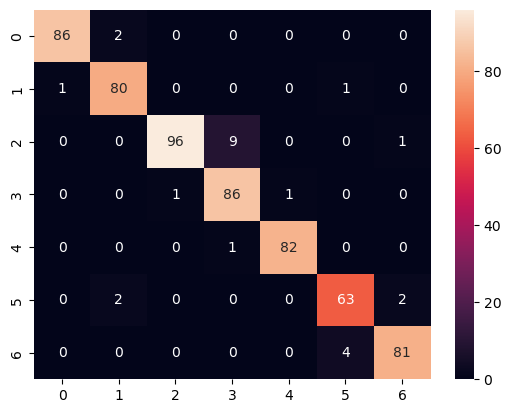

In [13]:
conf_mat = confusion_matrix(y_pred, y_test)
sns.heatmap(conf_mat, annot=True)

In [14]:
clf_report = classification_report(y_pred, y_test)
print(clf_report)

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        88
           1       0.95      0.98      0.96        82
           2       0.99      0.91      0.95       106
           3       0.90      0.98      0.93        88
           4       0.99      0.99      0.99        83
           5       0.93      0.94      0.93        67
           6       0.96      0.95      0.96        85

    accuracy                           0.96       599
   macro avg       0.96      0.96      0.96       599
weighted avg       0.96      0.96      0.96       599



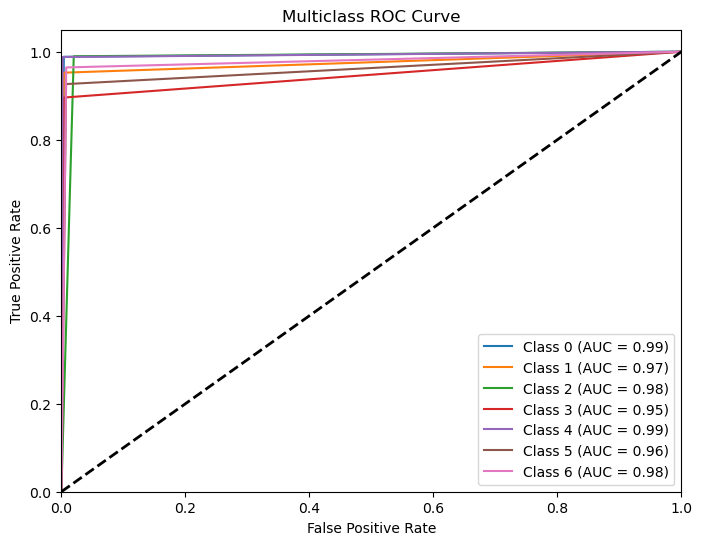

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Binarize the output for multiclass ROC AUC
y_test_bin = label_binarize(y_test, classes=range(7))
y_pred_bin = label_binarize(y_pred, classes=range(7))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_pred_bin[:, i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(7):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.show()